# Classification Track — Part A
## 05. Support Vector Machine (SVC)

**Notes from the algorithm list:** Tune C and kernel; scale features.

SVM finds the decision boundary that maximises the margin between classes (extended to multi-class via
one-vs-one internally in scikit-learn). Like KNN, SVM is distance/margin-based and therefore **requires scaled
features** — already handled in notebook `00`. `probability=True` is enabled so we can compute ROC-AUC.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              confusion_matrix, classification_report, roc_auc_score)
from sklearn.preprocessing import label_binarize
import os

RANDOM_STATE = 42
sns.set_style("whitegrid")

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze("columns")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze("columns")
class_map = pd.read_csv("../data/processed/class_mapping.csv", index_col=0)["class_name"].to_dict()
class_names = [class_map[i] for i in sorted(class_map.keys())]

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Classes:", class_names)

X_train: (1688, 21)  X_test: (423, 21)
Classes: ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']


In [2]:
ALGO_KEY = "svm"
ALGO_DISPLAY = "Support Vector Machine (SVC)"

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale']
}
grid = GridSearchCV(SVC(probability=True, random_state=RANDOM_STATE), param_grid, cv=5,
                     scoring='f1_weighted', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV weighted-F1:", round(grid.best_score_, 4))
svm = grid.best_estimator_

C:\Users\Navee\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Best params: {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
Best CV weighted-F1: 0.9655


### Effect of C and kernel (hyperparameter tuning)

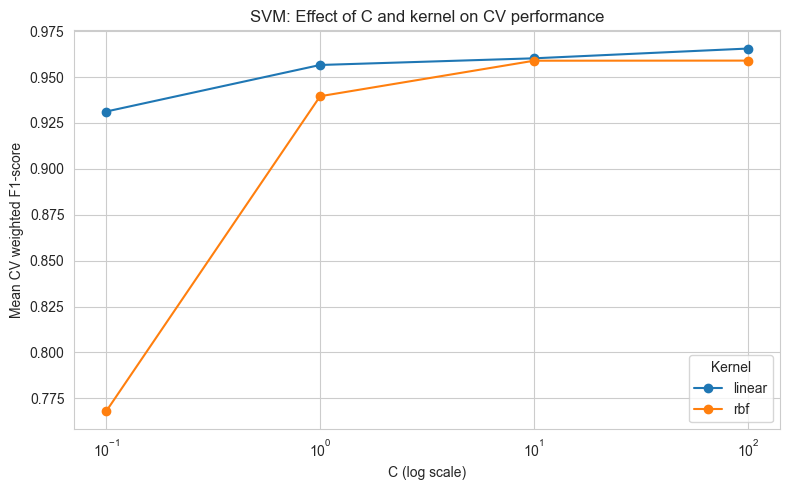

In [3]:
results_df = pd.DataFrame(grid.cv_results_)
pivot = results_df.pivot_table(index='param_C', columns='param_kernel', values='mean_test_score')

plt.figure(figsize=(8, 5))
for kernel in pivot.columns:
    plt.plot(pivot.index, pivot[kernel], marker='o', label=kernel)
plt.xscale('log')
plt.xlabel("C (log scale)")
plt.ylabel("Mean CV weighted F1-score")
plt.title("SVM: Effect of C and kernel on CV performance")
plt.legend(title="Kernel")
plt.tight_layout()
plt.savefig("../results/fig_svm_tuning.png", bbox_inches="tight")
plt.show()

**Discussion:** `C` controls the trade-off between a wide margin and correctly classifying training points —
small `C` allows more margin violations (simpler, more regularised boundary), large `C` fits the training data more
tightly (risk of overfitting). The `rbf` kernel allows non-linear decision boundaries, while `linear` restricts the
model to a linear boundary in feature space; the grid search above selects whichever combination generalises best
under 5-fold cross-validation.

### Evaluation

In [4]:
y_pred = svm.predict(X_test)
y_proba = svm.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average='weighted')
precision_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall_weighted = recall_score(y_test, y_pred, average='weighted')

y_test_bin = label_binarize(y_test, classes=sorted(class_map.keys()))
roc_auc_ovr = roc_auc_score(y_test_bin, y_proba, multi_class='ovr', average='weighted')

print(f"Accuracy           : {acc:.4f}")
print(f"Weighted Precision  : {precision_weighted:.4f}")
print(f"Weighted Recall     : {recall_weighted:.4f}")
print(f"Weighted F1-score   : {f1_weighted:.4f}")
print(f"ROC-AUC (OvR, wtd)  : {roc_auc_ovr:.4f}")
print()
print("Full classification report:")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

Accuracy           : 0.9764
Weighted Precision  : 0.9773
Weighted Recall     : 0.9764
Weighted F1-score   : 0.9765
ROC-AUC (OvR, wtd)  : 0.9989

Full classification report:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      1.00      1.00        54
      Normal_Weight       0.98      0.95      0.96        58
     Obesity_Type_I       1.00      0.99      0.99        70
    Obesity_Type_II       0.97      1.00      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.90      0.97      0.93        58
Overweight_Level_II       0.98      0.95      0.96        58

           accuracy                           0.98       423
          macro avg       0.98      0.98      0.98       423
       weighted avg       0.98      0.98      0.98       423



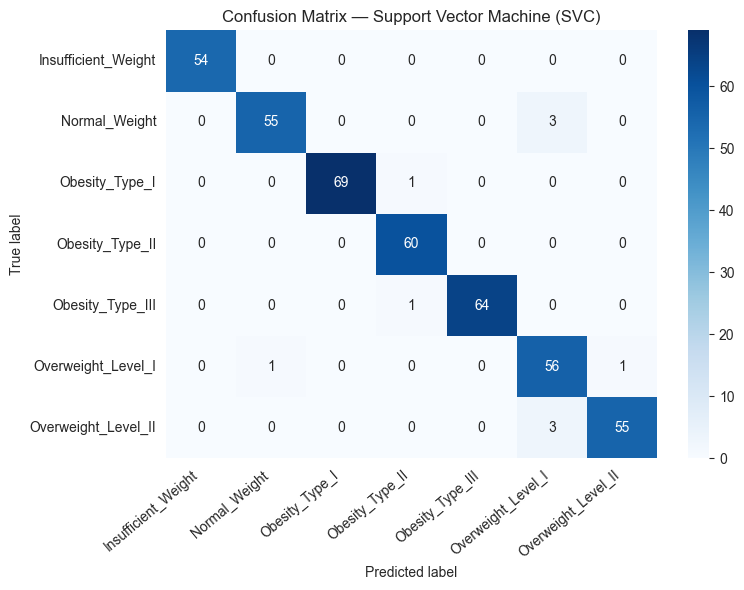

In [5]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Confusion Matrix — {ALGO_DISPLAY}")
plt.xticks(rotation=40, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"../results/fig_confusion_matrix_{ALGO_KEY}.png", bbox_inches="tight")
plt.show()

In [6]:
results_path = "../results/part_a_results.csv"
row = pd.DataFrame([{
    "Algorithm": ALGO_DISPLAY,
    "Accuracy": round(acc, 4),
    "Precision_weighted": round(precision_weighted, 4),
    "Recall_weighted": round(recall_weighted, 4),
    "F1_weighted": round(f1_weighted, 4),
    "ROC_AUC_OvR": round(roc_auc_ovr, 4),
}])

if os.path.exists(results_path):
    existing = pd.read_csv(results_path)
    existing = existing[existing["Algorithm"] != ALGO_DISPLAY]
    combined = pd.concat([existing, row], ignore_index=True)
else:
    combined = row

combined.to_csv(results_path, index=False)
print("Logged result to part_a_results.csv:")
combined

Logged result to part_a_results.csv:


,Algorithm,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,ROC_AUC_OvR
0,Logistic Regression,0.9078,0.9088,0.9078,0.9071,0.9921
1,K-Nearest Neighbors,0.9243,0.9230,0.9243,0.9229,0.9864
2,Naive Bayes (Gaussian),0.7447,0.7849,0.7447,0.7351,0.9497
3,Decision Tree,0.9811,0.9814,0.9811,0.9810,0.9955
4,Support Vector Machine (SVC),0.9764,0.9773,0.9764,0.9765,0.9989
